<a href="https://colab.research.google.com/github/imannolM/agente-topo/blob/main/agente_topo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Intalar dependencias

In [77]:
%pip install -q langchain
%pip install -q langgraph
%pip install -q langchain-community
%pip install -q langchain-cohere
%pip install -q langchain-groq
%pip install -q faiss-cpu langchain-text-splitters pymupdf
%pip install -q requests
%pip install -q langchain-classic
%pip install -q pymysql
%pip install -q mysql-connector-python

#las pasaremos a un requirements.txt

In [78]:
#las pasaremos a un .env
from google.colab import userdata

GROQ_API_KEY = userdata.get('GROQ_API_KEY')
COHERE_API_KEY = userdata.get('COHERE_API_KEY')

# Conexión con LLMs

In [79]:
from langchain_groq import ChatGroq

llm_groq = ChatGroq(
    model = 'llama-3.3-70b-versatile',
    groq_api_key = GROQ_API_KEY,
    temperature = 0
)

## Creamos el prompt_triaje y la función triaje

In [80]:
from typing import Literal, List, Dict, Optional
from pydantic import BaseModel, Field
from langchain_core.prompts import ChatPromptTemplate

# 1. El nuevo Prompt de Triaje Dinámico
PROMPT_TRIAJE = """
Eres el clasificador y enrutador principal del despacho inmobiliario Terrenos TOPO.
El usuario actual tiene el rol de: {user_role}.

Tu ÚNICA tarea es clasificar la intención del usuario y llenar los campos solicitados. NUNCA respondas con texto libre.

Opciones de clasificación (decision):
- CONSULTAR_DOCUMENTACION: Dudas sobre procesos, requisitos, políticas (PDFs institucionales).
- CONSULTAR_DB: Consultar el estado de un trámite, folios, métricas, o catálogo de propiedades.
- MODIFICAR_DB_O_DOCS: Peticiones explícitas para actualizar, aprobar, cambiar estatus o agregar registros.
- ANALISIS_DATOS: Peticiones de reportes, resúmenes estadísticos o generación de gráficos.
- PEDIR_INFO: Casos ambiguos o saludos.
- AGENDAR_CITA: Peticiones explícitas para agendar una cita.

Si el usuario solicita una modificación, intenta extraer el 'campo_a_modificar' y el 'nuevo_valor'.
"""

In [81]:
class TriajeOut(BaseModel):
    decision: Literal["CONSULTAR_DOCUMENTACION", "CONSULTAR_DB", "MODIFICAR_DB_O_DOCS", "ANALISIS_DATOS", "PEDIR_INFO", "AGENDAR_CITA"]
    urgencia: Literal["BAJA", "MEDIANA", "ALTA"]
    campos_faltantes: List[str] = Field(default_factory=list)
    # Nuevos campos para capturar qué quiere cambiar exactamente el usuario
    campo_a_modificar: Optional[str] = Field(default=None, description="El nombre de la columna o dato a cambiar (ej. estatus, costo, descripcion)")
    nuevo_valor: Optional[str] = Field(default=None, description="El nuevo valor a asignar (ej. Aprobado, 5000)")

In [82]:
from langchain_core.messages import content
from langchain_core.messages import SystemMessage, HumanMessage

prompt_triaje_template = ChatPromptTemplate.from_messages([
    ("system", PROMPT_TRIAJE),
    ("human", "{pregunta}")
])

chain_de_triaje = prompt_triaje_template | llm_groq.with_structured_output(TriajeOut)

# RAG

In [83]:
from pathlib import Path
from langchain_community.document_loaders import PyMuPDFLoader

docs = []

for documento in Path("/content/drive/MyDrive/documentos-topo").glob("*.pdf"):
  try:
    loader = PyMuPDFLoader(str(documento))
    docs.extend(loader.load())
    print(f"Archivo cargado: {documento.name}")
  except Exception as e:
    print(f"Error cargando archivo: {documento.name}: {e}")

print(f'Total de documentos cargados: {len(docs)}')

Archivo cargado: 01_perfil_corporativo.pdf
Archivo cargado: 02_departamento_topografia.pdf
Archivo cargado: 03_departamento_juridico.pdf
Archivo cargado: 04_departamento_administrativo.pdf
Archivo cargado: 06_departamento_bienes_raices.pdf
Archivo cargado: 05_administracion_financiera.pdf
Archivo cargado: 07_politicas_generales.pdf
Archivo cargado: 08_faqs_por_usuario.pdf
Total de documentos cargados: 37


Text Splitting (Segmentación)

In [84]:
from langchain_text_splitters import RecursiveCharacterTextSplitter

splitter = RecursiveCharacterTextSplitter(chunk_size = 300, chunk_overlap = 30)
chunks = splitter.split_documents(docs)
print(f'Total de chunks: {len(chunks)}')

Total de chunks: 339


In [85]:
#podemos ver los chunks si es necesario
# for chunk in chunks:
#   print(chunk)
#   print('_________________________')

Embedding (vectorización)

In [86]:
from langchain_cohere import CohereEmbeddings

modelo_embeddings = CohereEmbeddings(
    model="embed-multilingual-v3.0",
    cohere_api_key = COHERE_API_KEY
)

In [87]:
from re import search
from langchain_community.vectorstores import FAISS

vectorstore = FAISS.from_documents(chunks, modelo_embeddings)

retriever = vectorstore.as_retriever(
    search_type = 'similarity_score_threshold',
    search_kwargs = {'score_threshold': 0.3, 'k': 4}
)

Creamos el prompt del RAG

In [88]:
from langchain_core.prompts import ChatPromptTemplate
from langchain_classic.chains.combine_documents import create_stuff_documents_chain

# Modificamos el System Prompt con las directrices específicas del proyecto
PROMPT_RAG_TOPO = """
Eres el asistente experto y especialista del despacho inmobiliario Terrenos TOPO.
Tu objetivo es responder de forma clara, profesional y concisa las consultas sobre la documentación y políticas de la empresa (Topografía, Jurídico, Administrativo y Bienes Raíces).

REGLAS ESTRICTAS DE OPERACIÓN:
1. Responde ÚNICAMENTE utilizando el fragmento de contexto provisto, el cual proviene de los documentos institucionales oficiales de la empresa.
2. Si la respuesta no se encuentra explícitamente en el contexto proporcionado, di de forma directa y amable: "Lo siento, no dispongo de información oficial sobre ese tema en este momento." No intentes inventar ni adivinar datos.
3. Adapta sutilmente tu tono según el contexto de la consulta (sé servicial con Clientes, técnico y colaborativo con Empleados/Socios, y formal con el Administrador).
4. NUNCA menciones términos técnicos del sistema como "los fragmentos de texto provistos", "según el contexto enviado" o "el RAG". Para el usuario, tú conoces la empresa a la perfección de forma natural.
"""

prompt_rag = ChatPromptTemplate(
    [
        ('system', PROMPT_RAG_TOPO),
        ('human', 'Contexto de los documentos oficiales:\n{context}\n\nPregunta formulada: {input}')
    ]
)

document_chain = create_stuff_documents_chain(llm_groq, prompt_rag)

Creamos la función que estructura la únion del retriever y document_chain. Creamos la función RAG

In [89]:
# --- FUNCIÓN RAG (Sincronizada con el prompt amigable de Terrenos TOPO) ---
def busqueda_de_respuestas_RAG(pregunta: str) -> Dict:
    documentos_relacionados = retriever.invoke(pregunta)
    frase_no_info = "Lo siento, no dispongo de información oficial sobre ese tema en este momento."

    if not documentos_relacionados:
        return {
            'respuesta': frase_no_info,
            'citaciones': [],
            'documentos_encontrados': False
        }

    answer = document_chain.invoke({
        'input': pregunta,
        'context': documentos_relacionados
    })

    # Verificamos si el LLM generó la frase de contingencia
    if answer.strip().rstrip('.!?') == frase_no_info.rstrip('.!?'):
        return {
            'respuesta': frase_no_info,
            'citaciones': [],
            'documentos_encontrados': False
        }

    return {
        'respuesta': answer,
        'citaciones': documentos_relacionados,
        'documentos_encontrados': True
    }

In [90]:
r = busqueda_de_respuestas_RAG('Quiero actualizar mis datos catastrales porque el predio aparece con una superficie diferente a la real, ¿qué necesito hacer?')
print(r)

{'respuesta': 'Para actualizar tus datos catastrales debido a una discrepancia en la superficie del predio, es recomendable realizar un levantamiento topográfico catastral. Este proceso implica la medición precisa de la superficie real del predio por un perito topográfico. \n\nUna vez que se obtengan los resultados del levantamiento, si se confirma que la superficie real es distinta a la escriturada, el perito topográfico te orientará sobre el trámite de corrección de superficie que deberás seguir. Este trámite generalmente requiere la coordinación con el departamento Jurídico de nuestra empresa.\n\nAdemás, es importante verificar el requisito específico de la autoridad ante la que se presentará el documento, ya que las autoridades catastrales suelen solicitar levantamientos con una antigüedad no mayor a 6-12 meses.\n\nEl costo del levantamiento topográfico catastral puede variar según la superficie del predio, pero actualmente tenemos un costo de $400 MXN para este servicio.\n\nEspero

In [91]:
len(r['citaciones'])

4

# Agente con LangGraph

In [92]:
from typing import TypedDict, List, Dict, Any, Optional, Annotated, Sequence
from langchain_core.messages import BaseMessage

# 1. Definimos AgentState, expandido solo con los roles de seguridad
class AgentState(TypedDict, total=False):
    messages: list[Any]

    # Datos de sesión enviados por Streamlit
    user_role: str
    user_folio: Optional[str]

    # Datos de la solicitud actual
    folio_consultado: Optional[str]
    tabla_analisis: Optional[str]
    triaje: dict

    # Confirmación de modificación al administrador
    confirmacion_modificacion: bool

    # Streamlit podrá usar gráfico_generado para mostrarlo
    grafico_generado: Optional[str]

    # Resultado del agente
    respuesta: Optional[str]
    citaciones: Optional[list]
    rag_exito: bool
    accion_final: str

Vamos a crear una función auxiliar de apoyo

In [93]:
# --- FUNCIÓN AUXILIAR DE APOYO ---
def obtener_pregunta_del_estado(state: AgentState) -> str:
    """Obtiene la última pregunta del usuario desde messages."""
    messages = state.get("messages", [])

    if not messages:
        raise ValueError("El estado no contiene mensajes para procesar.")

    ultimo_mensaje = messages[-1]

    if isinstance(ultimo_mensaje, tuple):
        return str(ultimo_mensaje[1])

    if hasattr(ultimo_mensaje, "content"):
        return str(ultimo_mensaje.content)

    return str(ultimo_mensaje)

In [94]:
# --- NODO: TRIAJE ---
def nodo_triaje(state: AgentState) -> dict:
    print("🔮 Ejecutando nodo triaje...")
    texto_pregunta = obtener_pregunta_del_estado(state)
    rol_usuario = normalizar_rol(
        state.get("user_role", "cliente")
    )

    print(f"💬 Pregunta procesada: '{texto_pregunta}' | Rol detectado: {rol_usuario}")

    try:
        salida: TriajeOut = chain_de_triaje.invoke({
            "user_role": rol_usuario,
            "pregunta": texto_pregunta
        })
        return {"triaje": salida.model_dump()}
    except Exception as e:
        print(f"⚠️ Error en triaje, usando fallback PEDIR_INFO: {e}")
        return {
            "triaje": {
                "decision": "PEDIR_INFO",
                "urgencia": "BAJA",
                "campos_faltantes": [],
                "campo_a_modificar": None,
                "nuevo_valor": None
            }
        }

In [95]:
# --- NODO: CONSULTAR DOCUMENTACIÓN (RAG) ---
def nodo_consultar_documentacion(state: AgentState) -> dict:
    print("📚 Ejecutando nodo consultar_documentacion (RAG)...")
    texto_pregunta = obtener_pregunta_del_estado(state)

    respuesta_RAG = busqueda_de_respuestas_RAG(texto_pregunta)

    update = {
        "respuesta": respuesta_RAG["respuesta"],
        "citaciones": respuesta_RAG["citaciones"],
        "rag_exito": respuesta_RAG["documentos_encontrados"]
    }

    if respuesta_RAG["documentos_encontrados"]:
        update["accion_final"] = "DOCUMENTACION_RESUELTA"
    else:
        update["accion_final"] = "PEDIR_INFO"

    return update

# Aquí insertaré algunas funciones para corregir bugs y solucionar problemas de escalabilidad del código

In [96]:
# Creación de un modulo/función de utilidad
import re

def mapear_folio_a_tabla(texto_pregunta: str):
    """
    Analiza el texto buscando patrones como TOP-00001, JUR-00997, VTA-00995, etc.
    Retorna: (nombre_tabla, columna_id, folio_completo) o (None, None, None)
    """
    # Expresión regular que captura el prefijo de 2 a 4 letras y el número completo
    patron = r'\b([A-Z]{2,4}-\d{4,5})\b'
    match = re.search(patron, texto_pregunta.upper())

    if not match:
        return None, None, None

    folio_completo = match.group(1)
    prefijo = folio_completo.split('-')[0]

    # Mapeo dinámico basado en las reglas del negocio y tu archivo SQL
    MAPEO_PREFIJOS = {
        "TOP": ("topografia_proyectos", "id_proyecto"),
        "JUR": ("juridico_tramites", "id_tramite"),
        "ADM": ("administrativo_catastral", "id_tramite"),
        "TT": ("bienes_raices_inventario", "clave_terreno"),
    }

    tabla, columna_id = MAPEO_PREFIJOS.get(prefijo, (None, None))
    return tabla, columna_id, folio_completo

In [97]:
# Matriz de permisos escalable
# ___________Roles y permisos_________
ROLES_VALIDOS = {"administrador", "empleado", "cliente"}

def normalizar_rol(rol: str) -> str:
    rol_normalizado = rol.strip().lower()

    if rol_normalizado not in ROLES_VALIDOS:
        raise ValueError(f"Rol no autorizado: {rol_normalizado}")

    return rol_normalizado

TABLA_INVENTARIO = "bienes_raices_inventario"

PERMISOS_LECTURA = {
    "administrador": "*",
    "empleado": [
        "topografia_proyectos",
        "juridico_tramites",
        "administrativo_catastral",
        TABLA_INVENTARIO,
        "ventas_analitica",
    ],
    "cliente": [TABLA_INVENTARIO],
}


def validar_acceso_tabla(
    rol: str,
    tabla: str,
    folio_pregunta: str = None,
    folio_usuario_autenticado: str = None,
) -> bool:
    """Valida el acceso de lectura según rol, tabla y folio autenticado."""
    rol = normalizar_rol(rol)

    if rol in {"administrador", "admin"}:
        return True

    # Inventario inmobiliario: catálogo público para cualquier visitante.
    if tabla == TABLA_INVENTARIO:
        return True

    # Cliente: solo puede consultar su propio trámite mediante un folio coincidente.
    if rol == "cliente":
        return bool(
            folio_pregunta
            and folio_usuario_autenticado
            and folio_pregunta == folio_usuario_autenticado
        )

    # Socio y empleado: acceso solo a las tablas expresamente autorizadas.
    tablas_permitidas = PERMISOS_LECTURA.get(rol, [])
    return tabla in tablas_permitidas

A partir de aquí crearemos las funciones lógicas para los nodos restantes.

Usaremos Aiven para la db

In [98]:
# montamos drive
from google.colab import drive
drive.mount('/content/drive')

# Conexión con Aiven
import mysql.connector

HOST_AIVEN = userdata.get('HOST_AIVEN')
PORT_AIVEN = userdata.get('PORT_AIVEN')
USER_AIVEN = userdata.get('USER_AIVEN')
PASSWORD_AIVEN = userdata.get('PASSWORD_AIVEN')
DATABASE_AIVEN = userdata.get('DATABASE_AIVEN')

conn = mysql.connector.connect(
    host=HOST_AIVEN,
    port=PORT_AIVEN,
    user=USER_AIVEN,
    password=PASSWORD_AIVEN,
    database=DATABASE_AIVEN,
    ssl_ca="/content/drive/MyDrive/documentos-topo/ca.pem"
)
cursor = conn.cursor()
cursor.execute("SELECT COUNT(*) FROM ventas_analitica;")
print(cursor.fetchone())

cursor.execute("SHOW DATABASES;")
for db in cursor:
    print(db)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
(1000,)
('defaultdb',)
('information_schema',)
('mysql',)
('performance_schema',)
('sys',)
('terrenos_topo_db',)


Voy a crear la tabla para guardar las peticiones

In [99]:
cursor = conn.cursor()

sql = """
CREATE TABLE IF NOT EXISTS administrativo_solicitudes (
    id_solicitud INT AUTO_INCREMENT PRIMARY KEY,
    rol_solicitante VARCHAR(50) NOT NULL,
    folio_afectado VARCHAR(20),
    campo_modificar VARCHAR(50),
    nuevo_valor VARCHAR(255),
    peticion_original TEXT,
    estatus ENUM('pendiente', 'aprobada', 'rechazada') DEFAULT 'pendiente',
    fecha_creacion TIMESTAMP DEFAULT CURRENT_TIMESTAMP
) ENGINE=InnoDB;
"""

cursor.execute(sql)
conn.commit()

print("Tabla creada correctamente.")

Tabla creada correctamente.


In [100]:
cursor.execute("SHOW TABLES;")

for tabla in cursor.fetchall():
    print(tabla)

('administrativo_catastral',)
('administrativo_solicitudes',)
('bienes_raices_inventario',)
('contabilidad_finanzas',)
('juridico_tramites',)
('topografia_proyectos',)
('ventas_analitica',)


In [101]:
def obtener_conexion_db():
    HOST_AIVEN = userdata.get('HOST_AIVEN')
    PORT_AIVEN = userdata.get('PORT_AIVEN')
    USER_AIVEN = userdata.get('USER_AIVEN')
    PASSWORD_AIVEN = userdata.get('PASSWORD_AIVEN')
    DATABASE_AIVEN = userdata.get('DATABASE_AIVEN')

    return mysql.connector.connect(
        host=HOST_AIVEN,
        port=PORT_AIVEN,
        user=USER_AIVEN,
        password=PASSWORD_AIVEN,
        database=DATABASE_AIVEN,
        ssl_ca="/content/drive/MyDrive/documentos-topo/ca.pem"
    )

In [102]:
# Esta función se encarga de insertar un registro limpio cada vez que el socio pida un cambio
def crear_solicitud_pendiente(rol: str, folio: str, campo: str, valor: str, peticion_original: str) -> dict:
    """
    Guarda la petición de modificación en la tabla 'administrativo_solicitudes'
    para que el Administrador la revise posteriormente.
    """
    print(f"📝 Registrando nueva solicitud de modificación para el folio {folio}...")
    try:
        conexion = obtener_conexion_db()
        with conexion.cursor() as cursor:
            sql = """
                INSERT INTO administrativo_solicitudes
                (rol_solicitante, folio_afectado, campo_modificar, nuevo_valor, peticion_original)
                VALUES (%s, %s, %s, %s, %s)
            """
            cursor.execute(sql, (rol, folio, campo, valor, peticion_original))
            conexion.commit()

        conexion.close()
        return {
            "exito": True,
            "mensaje": f"Tu solicitud para modificar el folio '{folio}' ha sido registrada exitosamente. Un Administrador revisará el cambio sugerido ({campo} -> {valor}) a la brevedad."
        }
    except Exception as e:
        print(f"❌ Error al crear solicitud en MySQL: {e}")
        return {
            "exito": False,
            "mensaje": "Hubo un error interno al intentar enviar tu solicitud de modificación."
        }

Política de campos

In [103]:
# Campos que el administrador tiene permitido modificar por tabla.
# Usa exclusivamente nombres reales de columnas de MySQL.
CAMPOS_MODIFICABLES = {
    "topografia_proyectos": {
        "estatus",
        "costo_total",
        "anticipo",
        "restante",
        "fecha_estimada_entrega"
    },
    "juridico_tramites": {
        "estatus",
        "documentos_faltantes",
        "precio",
        "anticipo",
        "restante"
    },
    "administrativo_catastral": {
        "estatus",
        "documentos_entregados",
        "costo"
    },
    "bienes_raices_inventario": {
        "estatus",
        "precio_m2",
        "precio_total",
        "documentos_disponibles",
        "enganche_minimo",
        "socio_asignado"
    },
}

# Alias que el usuario o el LLM puede mencionar, pero que se convierten
# a nombres seguros y conocidos de la base de datos.
ALIAS_CAMPOS = {
    "estado": "estatus",
    "status": "estatus",
    "costo": "precio_total",
    "precio de venta": "precio_total",
}


def obtener_campo_autorizado(tabla: str, campo_solicitado: str | None) -> str | None:
    """Devuelve una columna permitida o None si no está autorizada."""
    if not campo_solicitado:
        return None

    campo_normalizado = campo_solicitado.strip().lower()
    campo_bd = ALIAS_CAMPOS.get(campo_normalizado, campo_normalizado)

    if campo_bd in CAMPOS_MODIFICABLES.get(tabla, set()):
        return campo_bd

    return None

In [104]:
# Vamos a consultar las columnas de la tabla bienes_raices_inventario, vamos a restringir datos sensibles de las propiedades en las consultas públicas
cursor = conn.cursor(dictionary=True)

cursor.execute("DESCRIBE bienes_raices_inventario")

for columna in cursor.fetchall():
    print(columna["Field"])

clave_terreno
ubicacion
superficie_m2
uso_suelo
precio_m2
precio_total
documentos_disponibles
enganche_minimo
estatus
socio_asignado


In [105]:
# Aquí definimos los campos que serán publicos de la tabla bienes_raices_inventario
CAMPOS_PUBLICOS_INVENTARIO = (
    "clave_terreno",
    "ubicacion",
    "superficie_m2",
    "uso_suelo",
    "precio_m2",
    "precio_total",
    "estatus"
)

In [106]:
# --- FUNCIÓN LOGICA: CONSULTAR BASE DE DATOS (SCONZADA CON SQL REAL) ---
import pymysql

def consulta_base_de_datos(texto_pregunta: str, user_role: str, user_folio: str = None):
    """
    Herramienta para consultar datos mediante introspección del folio.
    """
    # 1. Identificar tabla y folio de forma dinámica
    tabla, columna_id, folio_completo = mapear_folio_a_tabla(texto_pregunta)

    rol = normalizar_rol(user_role)

    # Caso especial: consulta pública al catálogo de Bienes Raíces
    texto_normalizado = texto_pregunta.lower()

    if not tabla and any(
        termino in texto_normalizado
        for termino in [
            "bienes raíces",
            "bienes raices",
            "propiedades",
            "terrenos en venta"
        ]
    ):
        tabla = TABLA_INVENTARIO
        columna_id = None

    if not tabla:
        return (
            "No logré identificar la propiedad o trámite al que haces referencia "
            "en tu consulta. Por favor provee un folio válido (Ej: TOP-00001)."
        )

    # 2. Validar Seguridad y Roles
    if not validar_acceso_tabla(rol, tabla, folio_completo, user_folio):
        return f"Acceso Denegado: Tu rol de '{user_role}' no tiene permisos para consultar la tabla '{tabla}' o el folio especificado no te pertenece."

    # 3. Conexión a la DB (Aiven MySQL)
    try:
        conexion = obtener_conexion_db()
        cursor = conexion.cursor(dictionary=True)

        columnas_publicas_sql = ", ".join(
            f"`{columna}`" for columna in CAMPOS_PUBLICOS_INVENTARIO
        )

        # Cliente: inventario público, solo campos comerciales y terrenos disponibles.
        # Esta condición tiene prioridad incluso si el cliente proporciona TT-0101.
        if tabla == TABLA_INVENTARIO and rol == "cliente":
            sql = f"""
                SELECT {columnas_publicas_sql}
                FROM `{TABLA_INVENTARIO}`
                WHERE LOWER(TRIM(`estatus`)) = %s
            """
            parametros = ["disponible"]

            # Si consulta un terreno concreto, se filtra también por su clave.
            if columna_id and folio_completo:
                sql += f" AND `{columna_id}` = %s"
                parametros.append(folio_completo)

            sql += " LIMIT 10"
            cursor.execute(sql, tuple(parametros))

        elif columna_id and folio_completo:
            # Administrador y empleado pueden consultar el registro completo por folio.
            sql = f"SELECT * FROM `{tabla}` WHERE `{columna_id}` = %s"
            cursor.execute(sql, (folio_completo,))

        else:
            # Consultas internas generales.
            sql = f"SELECT * FROM `{tabla}` LIMIT 10"
            cursor.execute(sql)

        resultados = cursor.fetchall()
        cursor.close()
        conexion.close()

        if not resultados:
            return f"No se encontraron registros en la tabla '{tabla}' con el identificador provisto."

        # Al ser un diccionario, el LLM recibirá pares clave-valor dinámicos sin importar el orden de las columnas
        return str(resultados)

    except Exception as e:
        return f"Error al ejecutar la consulta dinámica: {str(e)}"

# --- FUNCIÓN LOGICA: MODIFICAR BASE DE DATOS (SINCROZADA CON SQL REAL) ---
def modificacion_base_de_datos(
    pregunta: str,
    user_role: str,
    datos_modificacion: dict | None = None,
    confirmada_por_admin: bool = False,
) -> dict:
    """Gestiona solicitudes y modificaciones seguras en la base de datos."""
    rol = normalizar_rol(user_role)
    datos_modificacion = datos_modificacion or {}

    folio_target = datos_modificacion.get("folio")
    campo_solicitado = datos_modificacion.get("campo_a_modificar")
    nuevo_valor = datos_modificacion.get("nuevo_valor")

    if not folio_target or not campo_solicitado or not nuevo_valor:
        return {
            "respuesta": (
                "Necesito el folio, el campo que deseas modificar y el nuevo valor "
                "para registrar o realizar el cambio."
            ),
            "db_exito": False,
        }

    tabla, columna_id, folio_completo = mapear_folio_a_tabla(folio_target)

    if not tabla or not columna_id:
        return {
            "respuesta": "No pude identificar una tabla válida para el folio indicado.",
            "db_exito": False,
        }

    # El campo nunca se inserta en SQL sin validación previa.
    campo = obtener_campo_autorizado(tabla, campo_solicitado)

    if not campo:
        return {
            "respuesta": (
                f"El campo '{campo_solicitado}' no está autorizado para modificarse "
                "en este registro."
            ),
            "db_exito": False,
        }

    # El socio solo propone cambios; nunca escribe directamente.
    if rol == "empleado":
        resultado = crear_solicitud_pendiente(
            rol=rol,
            folio=folio_completo,
            campo=campo,
            valor=str(nuevo_valor),
            peticion_original=pregunta,
        )
        return {
            "respuesta": resultado["mensaje"],
            "db_exito": resultado["exito"],
        }

    if rol not in {"administrador", "admin"}:
        return {
            "respuesta": "No tienes permisos para modificar registros ni generar solicitudes.",
            "db_exito": False,
        }

    # En Streamlit, este valor deberá venir de un botón de confirmación.
    if not confirmada_por_admin:
        return {
            "respuesta": (
                f"Confirmación requerida: se modificará '{campo}' del folio "
                f"'{folio_completo}' al valor '{nuevo_valor}'."
            ),
            "db_exito": False,
            "requiere_confirmacion": True,
        }

    conexion = None
    cursor = None

    try:
        conexion = obtener_conexion_db()
        cursor = conexion.cursor()

        # tabla, columna_id y campo proceden de listas permitidas.
        sql = f"""
            UPDATE `{tabla}`
            SET `{campo}` = %s
            WHERE `{columna_id}` = %s
        """

        cursor.execute(sql, (str(nuevo_valor), folio_completo))
        conexion.commit()

        if cursor.rowcount == 0:
            return {
                "respuesta": f"No se encontró el folio '{folio_completo}' para actualizar.",
                "db_exito": False,
            }

        return {
            "respuesta": (
                f"El registro '{folio_completo}' fue actualizado correctamente: "
                f"{campo} = {nuevo_valor}."
            ),
            "db_exito": True,
        }

    except Exception:
        if conexion:
            conexion.rollback()

        return {
            "respuesta": "No fue posible guardar el cambio. Inténtalo más tarde.",
            "db_exito": False,
        }

    finally:
        if cursor:
            cursor.close()
        if conexion:
            conexion.close()

# --- FUNCIÓN LOGICA: PEDIR INFORMACIÓN / SOPORTE ---
def soporte_pedir_info(pregunta: str) -> Dict:
    # Lógica para responder cuando algo es ambiguo o fuera de contexto
    return {
        "respuesta": "Para poder ayudarte mejor en Terrenos TOPO, ¿podrías ser un poco más específico con tu consulta o indicarme con qué departamento deseas hablar?",
        "info_completada": False
    }

# --- FUNCIÓN LOGICA: AGENDAR CITA ---
def gestion_agendar_cita(pregunta: str) -> Dict:
    # Nota: Aquí conectaremos con Google Calendar o una tabla de citas en el Chat 5
    return {
        "respuesta": "¡Por supuesto! Para agendar una cita con uno de nuestros asesores de Terrenos TOPO, por favor indícame tu nombre completo, teléfono y el día de tu preferencia.",
        "cita_agendada": False
    }

Aquí crearemos los nodos que interactúan directamente con al AgentState

In [107]:
import re
# --- NODO: CONSULTAR DB ---
def nodo_consultar_db(state: AgentState) -> dict:
    print("🗄️ Ejecutando nodo consultar_db...")
    texto_pregunta = obtener_pregunta_del_estado(state)
    rol = state.get("user_role", "cliente")
    folio_sesion = state.get("user_folio")

    # Detectamos el folio usando nuestra nueva función inteligente
    tabla, col_id, folio_detectado = mapear_folio_a_tabla(texto_pregunta)
    if folio_detectado:
        print(f"📌 Folio detectado para consulta: {folio_detectado}")

    # Ejecutamos la consulta dinámica
    resultado_db = consulta_base_de_datos(texto_pregunta, user_role=rol, user_folio=folio_sesion)

    return {
        "respuesta": resultado_db,
        "accion_final": "CONSULTA_DB_PROCESADA",
        "folio_consultado": folio_detectado
    }

# --- NODO: MODIFICAR DB O DOCS ---
def nodo_modificar_db_o_docs(state: AgentState) -> dict:
    print("✍️ Ejecutando nodo modificar_db_o_docs...")
    texto_pregunta = obtener_pregunta_del_estado(state)
    rol = state.get("user_role", "cliente")

    # Intentamos sacar el folio dinámicamente si no viene en el state
    _, _, folio_tramite = mapear_folio_a_tabla(texto_pregunta)
    if not folio_tramite:
        match = re.search(r'\b([A-Z]{2,4}-\d{4,5})\b', texto_pregunta.upper())
        if match:
            folio_tramite = match.group(1)

    # Rescatamos los parámetros exactos extraídos por el Triaje
    triaje_data = state.get("triaje", {})
    campo_mod = triaje_data.get("campo_a_modificar")
    nuevo_val = triaje_data.get("nuevo_valor")

    datos_modificacion = {
        "folio": folio_tramite,
        "campo_a_modificar": campo_mod,
        "nuevo_valor": nuevo_val
    }

    resultado_modificacion = modificacion_base_de_datos(
        texto_pregunta,
        user_role=rol,
        datos_modificacion=datos_modificacion,
        confirmada_por_admin=state.get("confirmacion_modificacion", False),
    )

    update = {
        "respuesta": resultado_modificacion["respuesta"],
        "folio": folio_tramite
    }

    if resultado_modificacion.get("requiere_confirmacion"):
        update["accion_final"] = "CONFIRMACION_REQUERIDA"
    elif resultado_modificacion["db_exito"]:
        update["accion_final"] = "MODIFICACION_EXITOSA"
    else:
        update["accion_final"] = "ERROR_PERMISOS"

    return update

# --- NODO: PEDIR INFO ---
def nodo_pedir_info(state: AgentState) -> dict:
    print("💬 Ejecutando nodo pedir_info...")
    texto_pregunta = obtener_pregunta_del_estado(state)

    resultado_soporte = soporte_pedir_info(texto_pregunta)

    return {
        "respuesta": resultado_soporte["respuesta"],
        "accion_final": "PEDIR_INFO_CLIENTE"
    }

# --- NODO: AGENDAR CITA ---
def nodo_agendar_cita(state: AgentState) -> dict:
    print("📅 Ejecutando nodo agendar_cita...")
    texto_pregunta = obtener_pregunta_del_estado(state)

    resultado_cita = gestion_agendar_cita(texto_pregunta)

    return {
        "respuesta": resultado_cita["respuesta"],
        "accion_final": "SOLICITAR_DATOS_CITA"
    }

A partir de aquí, crearemos las herrmaientas de análisis de datos ya que hemos añadido esta función al agente (Se ha modificado, por lo tanto, PROMT_TRIAJE)

In [108]:
import pandas as pd
import matplotlib.pyplot as plt
from langchain_core.tools import tool
from sqlalchemy import create_engine
import pymysql
import urllib.parse

# Solo estas tablas pueden cargarse para análisis desde MySQL.
TABLAS_ANALISIS_PERMITIDAS = {"ventas_analitica"}


def extraer_df_desde_mysql(nombre_tabla: str) -> pd.DataFrame:
    """Carga únicamente tablas aprobadas para análisis."""
    if nombre_tabla not in TABLAS_ANALISIS_PERMITIDAS:
        raise ValueError(f"La tabla '{nombre_tabla}' no está autorizada para análisis.")

    usuario = userdata.get("USER_AIVEN")
    password = urllib.parse.quote_plus(userdata.get("PASSWORD_AIVEN"))
    host = userdata.get("HOST_AIVEN")
    puerto = int(userdata.get("PORT_AIVEN"))
    db = userdata.get("DATABASE_AIVEN")
    ssl_ca = "/content/drive/MyDrive/documentos-topo/ca.pem"

    conexion_uri = (
        f"mysql+pymysql://{usuario}:{password}@{host}:{puerto}/{db}"
        f"?ssl_ca={ssl_ca}"
    )

    engine = create_engine(conexion_uri)

    # El nombre ya fue validado contra una lista cerrada.
    return pd.read_sql_table(nombre_tabla, con=engine)


def crear_herramientas_analisis(df: pd.DataFrame):
    """Crea herramientas sin ejecución arbitraria de código."""
    columnas_validas = set(df.columns)

    def validar_columna(columna: str) -> str:
        columna = columna.strip()

        if columna not in columnas_validas:
            disponibles = ", ".join(sorted(columnas_validas))
            raise ValueError(
                f"La columna '{columna}' no existe. Columnas disponibles: {disponibles}"
            )

        return columna

    @tool
    def informacion_dataset() -> str:
        """Muestra columnas, tipos de datos y una muestra de los primeros registros."""
        return (
            f"Columnas y tipos:\n{df.dtypes.to_string()}\n\n"
            f"Primeros registros:\n{df.head(5).to_string()}"
        )

    @tool
    def resumen_estadistico() -> str:
        """Genera un resumen estadístico de todo el conjunto de datos."""
        return df.describe(include="all").fillna("Sin dato").to_string()

    @tool
    def conteo_por_categoria(columna: str) -> str:
        """Cuenta registros agrupados por una columna categórica."""
        try:
            columna = validar_columna(columna)

            conteo = (
                df[columna]
                .fillna("Sin dato")
                .value_counts()
                .head(20)
            )

            return conteo.to_string()

        except ValueError as error:
            return str(error)

    @tool
    def generar_grafico(columna: str) -> str:
        """
        Genera un gráfico seguro para una columna.
        Si es numérica, crea un histograma; de otro modo, una gráfica de barras.
        """
        try:
            columna = validar_columna(columna)

            fig, ax = plt.subplots(figsize=(9, 5))

            if pd.api.types.is_numeric_dtype(df[columna]):
                df[columna].dropna().plot(
                    kind="hist",
                    bins=15,
                    ax=ax,
                    edgecolor="black",
                )
                ax.set_title(f"Distribución de {columna}")
                ax.set_xlabel(columna)
                ax.set_ylabel("Frecuencia")
            else:
                conteo = df[columna].fillna("Sin dato").value_counts().head(10)
                conteo.plot(kind="bar", ax=ax)
                ax.set_title(f"Registros por {columna}")
                ax.set_xlabel(columna)
                ax.set_ylabel("Cantidad")
                plt.xticks(rotation=45, ha="right")

            plt.tight_layout()

            ruta_grafico = "grafico_analisis.png"
            fig.savefig(ruta_grafico, bbox_inches="tight")
            plt.close(fig)

            return f"Gráfico generado correctamente en '{ruta_grafico}'."

        except ValueError as error:
            return str(error)

    return [
        informacion_dataset,
        resumen_estadistico,
        conteo_por_categoria,
        generar_grafico,
    ]

In [109]:
# Tablas de análisis autorizadas para cada rol.
# Ajusta la lista al ampliar el proyecto.
PERMISOS_ANALISIS = {
    "administrador": {"ventas_analitica"},
    "empleado": {"ventas_analitica"},
    "cliente": set(),
}


def resolver_tabla_analisis(state: AgentState) -> str:
    """Obtiene y valida la tabla de análisis solicitada."""
    rol = normalizar_rol(state.get("user_role", "cliente"))

    # Si no se especifica tabla, el análisis general se realiza sobre ventas.
    tabla_solicitada = state.get("tabla_analisis", "ventas_analitica")

    tablas_autorizadas = PERMISOS_ANALISIS.get(rol, set())

    if tabla_solicitada not in tablas_autorizadas:
        raise PermissionError(
            "Tu rol no tiene permiso para analizar esta información."
        )

    return tabla_solicitada

In [147]:
# Creamos el nodo_analisis_datos
from langchain_classic.agents import create_react_agent, AgentExecutor
from langchain_core.prompts import PromptTemplate

# --- NODO: ANÁLISIS DE DATOS (CORRECCIÓN AGENT_SCRATCHPAD) ---
def nodo_analisis_datos(state: AgentState) -> dict:
    print("📊 Ejecutando nodo de análisis de datos...")

    texto_pregunta = obtener_pregunta_del_estado(state)

    try:
        nombre_tabla = resolver_tabla_analisis(state)
    except PermissionError as error:
        return {
            "respuesta": str(error),
            "accion_final": "ACCESO_ANALISIS_DENEGADO",
        }

    try:
        df = extraer_df_desde_mysql(nombre_tabla)
    except Exception as error:
        return {
            "respuesta": "No fue posible cargar los datos para el análisis.",
            "accion_final": "ANALISIS_FALLIDO",
        }

    herramientas = crear_herramientas_analisis(df)

    texto_normalizado = texto_pregunta.lower()

    PALABRAS_GRAFICO = [
        "gráfico",
        "grafico",
        "gráfica",
        "grafica",
        "histograma",
        "visualización",
        "visualizacion",
        "diagrama",
        "barras",
        "pastel",
        "líneas",
        "lineas",
    ]

    solicita_grafico = any(
        palabra in texto_normalizado
        for palabra in PALABRAS_GRAFICO
    )

    # Si el usuario no pidió una visualización, el agente no puede generar una.
    if not solicita_grafico:
        herramientas = [
            herramienta
            for herramienta in herramientas
            if herramienta.name != "generar_grafico"
        ]

    # 🌟 CORRECCIÓN: Inyectamos el 'nombre_tabla' usando una f-string clásica en Python
    # para que no quede como una variable pendiente de LangChain.
    template_react = f"""Eres un experto en análisis de datos para Terrenos TOPO.
    Tienes acceso a las siguientes herramientas para consultar la tabla '{nombre_tabla}':

    {{tools}}

    Para usar una herramienta, debes usar obligatoriamente el siguiente formato exacto:

    Thought: Do I need to use a tool? Yes
    Action: la acción que vas a tomar, debe ser obligatoriamente uno de estos nombres: [{{tool_names}}]
    Action Input: la entrada de la herramienta
    Observation: el resultado que te arrojó la herramienta

    ... (puedes repetir este proceso de Thought/Action/Action Input/Observation varias veces si es necesario)

    Cuando ya tengas la conclusión final y no requieras herramientas, usa este formato:

    Thought: I know the final answer
    Final Answer: tu respuesta analítica bien redactada en español aquí.

    Reglas obligatorias:
    1. Utiliza siempre 'informaciones_df' o 'resumen_estadistico' antes de realizar cualquier cálculo matemático para conocer los datos de la tabla '{nombre_tabla}'.
    2. Si solicitan un gráfico, usa la herramienta 'generar_grafico' indicando únicamente el nombre exacto de una columna disponible. Nunca intentes escribir ni ejecutar código.
    3. Responde siempre de forma clara y analítica en español.
    4. Si el usuario solicita un resumen, una métrica, un conteo o una comparación, responde en texto. No generes gráficos.
    5. Solo genera un gráfico cuando el usuario lo pida explícitamente y la herramienta 'generar_grafico' esté disponible.
    6. No afirmes que generaste un gráfico si no utilizaste esa herramienta.

    Pregunta del usuario: {{input}}
    Thought: {{agent_scratchpad}}"""

    # Al usar from_template, LangChain solo detectará como variables: {tools}, {tool_names}, {input} y {agent_scratchpad}
    prompt = PromptTemplate.from_template(template_react)

    agente = create_react_agent(llm_groq, herramientas, prompt)
    ejecutor = AgentExecutor(
        agent=agente,
        tools=herramientas,
        verbose=True,
        handle_parsing_errors=True,
        return_intermediate_steps=True,
    )

    from pathlib import Path

    resultado = ejecutor.invoke({"input": texto_pregunta})

    se_genero_grafico = any(
        accion.tool == "generar_grafico"
        for accion, _ in resultado.get("intermediate_steps", [])
    )

    return {
        "respuesta": resultado["output"],
        "accion_final": "ANALISIS_COMPLETADO",
        "grafico_generado": (
            "grafico_analisis.png" if se_genero_grafico else None
        ),
    }

Aquí implementaremos aristas de desición



In [111]:
def arista_decision_triaje(state: AgentState) -> str:
    print("🔮 Decidiendo el flujo después del nodo 'triaje'...")
    tri = state["triaje"]
    decision = tri.get("decision")

    if decision == "CONSULTAR_DOCUMENTACION":
        print(" -> Ruta seleccionada: Base de Conocimiento (RAG)")
        return "rag"
    elif decision == "CONSULTAR_DB":
        print(" -> Ruta seleccionada: Consulta de datos/expedientes (MySQL)")
        return "consultar_db"
    elif decision == "MODIFICAR_DB_O_DOCS":
        print(" -> Ruta seleccionada: Modificación de registros")
        return "modificar_db"
    elif decision == "ANALISIS_DATOS":
        print(" -> Ruta seleccionada: Módulo de analítica y gráficos")
        return "analizar_datos"
    elif decision == "AGENDAR_CITA":
        print(" -> Ruta seleccionada: Agenda/Asesor humano")
        return "cita"
    else:
        print(" -> Ruta seleccionada: Pedir más información / Caso ambiguo")
        return "info"

In [112]:
def arista_decision_rag(state: AgentState) -> str:
    print("📝 Decidiendo el flujo después del nodo 'consultar_documentacion' (RAG)...")

    # Suponiendo que tu nodo de documentación guarda un flag 'rag_exito'
    if state.get("rag_exito"):
        print("RAG exitoso, finalizando el flujo.")
        return "ok"

    # Palabras clave adaptadas al contexto inmobiliario/topográfico de Terrenos TOPO
    KEYWORDS_AGENDAR_CITA = [
        "aprobacion", "aprobar", "excepcion", "liberacion", "autorizacion",
        "autorizar", "levantamiento", "deslinde", "firma de contrato", "asesor"
    ]

    pregunta = obtener_pregunta_del_estado(state)

    if any(keyword in pregunta.lower() for keyword in KEYWORDS_AGENDAR_CITA):
        print("El RAG no bastó, pero detectamos intención de cita presencial o técnica.")
        return "cita"

    print("El RAG no encontró respuesta suficiente; solicitando aclaraciones al usuario.")
    return "info"

MAPA DEL GRAFO

In [113]:
from langgraph.graph import StateGraph, END

workflow = StateGraph(AgentState)

# 1. Registro de todos tus Nodos del sistema
workflow.add_node("triaje", nodo_triaje)
workflow.add_node("consultar_documentacion", nodo_consultar_documentacion)
workflow.add_node("consultar_db", nodo_consultar_db)
workflow.add_node("modificar_db", nodo_modificar_db_o_docs)
workflow.add_node("analisis_datos", nodo_analisis_datos) # El nuevo nodo con las 4 tools
workflow.add_node("pedir_info", nodo_pedir_info)
workflow.add_node("agendar_cita", nodo_agendar_cita)

# Punto de entrada obligatorio
workflow.set_entry_point("triaje")

# 2. Aristas Condicionales desde el Triaje
workflow.add_conditional_edges(
    "triaje",
    arista_decision_triaje,
    {
        "rag": "consultar_documentacion",
        "consultar_db": "consultar_db",
        "modificar_db": "modificar_db",
        "analizar_datos": "analisis_datos",  # Enlace directo al módulo de analítica
        "cita": "agendar_cita",
        "info": "pedir_info"
    }
)

# 3. Aristas Condicionales desde el RAG (Siguiendo tu estructura del curso)
workflow.add_conditional_edges(
    "consultar_documentacion",
    arista_decision_rag,
    {
        "ok": END,                  # Si el RAG contestó bien, termina
        "cita": "agendar_cita",     # Si falló pero quiere cita, va al nodo cita
        "info": "pedir_info"        # Si falló por completo, pide más contexto
    }
)

# 4. Los demás nodos terminan directo el flujo al ejecutarse
workflow.add_edge("consultar_db", END)
workflow.add_edge("modificar_db", END)
workflow.add_edge("analisis_datos", END) # Tu nuevo flujo de datos termina limpio aquí
workflow.add_edge("pedir_info", END)
workflow.add_edge("agendar_cita", END)

# Compilación final
app = workflow.compile()

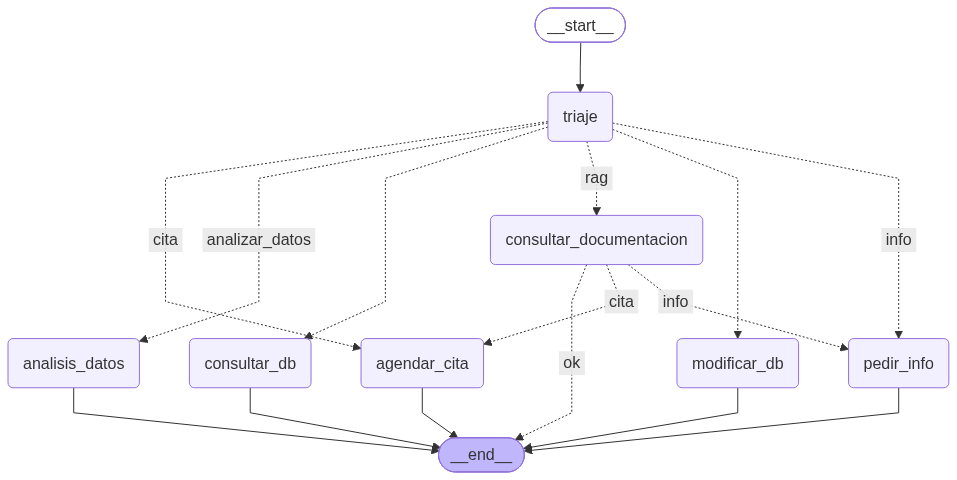

In [114]:
from IPython.display import display, Image

graph_bytes = app.get_graph().draw_mermaid_png()
display(Image(graph_bytes))

#PRUEBAS **____________________________________________________________________________**

In [115]:
inputs = {
    "messages": [("user", "¿Cuál es el estatus del trámite TOP-00001?")],
    "user_role": "cliente",
    "user_folio": "TOP-00001",
}

In [116]:
# Verificamos el mapeo y la política
print(mapear_folio_a_tabla("VTA-00001"))
print(obtener_campo_autorizado(
    "bienes_raices_inventario",
    "estatus"
))

(None, None, 'VTA-00001')
estatus


In [117]:
cursor = conn.cursor(dictionary=True)

cursor.execute("DESCRIBE bienes_raices_inventario")
for columna in cursor.fetchall():
    print(columna["Field"])

clave_terreno
ubicacion
superficie_m2
uso_suelo
precio_m2
precio_total
documentos_disponibles
enganche_minimo
estatus
socio_asignado


In [118]:
cursor.execute("SELECT * FROM bienes_raices_inventario LIMIT 3")

for registro in cursor.fetchall():
    print(registro)

{'clave_terreno': 'TT-0101', 'ubicacion': 'San Isidro, Timilpan, Edo. Méx.', 'superficie_m2': Decimal('48484.72'), 'uso_suelo': 'Industrial', 'precio_m2': Decimal('233.56'), 'precio_total': Decimal('11324091.20'), 'documentos_disponibles': 'certificado de no adeudo, titulo agrario', 'enganche_minimo': Decimal('2264818.24'), 'estatus': 'disponible', 'socio_asignado': 'Sofia Ramirez Cortes'}
{'clave_terreno': 'TT-0102', 'ubicacion': 'Barrio de Guadalupe, Chapa de Mota, Edo. Méx.', 'superficie_m2': Decimal('1801.43'), 'uso_suelo': 'Agricola / inversion', 'precio_m2': Decimal('196.09'), 'precio_total': Decimal('353242.41'), 'documentos_disponibles': 'escritura publica, titulo agrario', 'enganche_minimo': Decimal('35324.24'), 'estatus': 'disponible', 'socio_asignado': 'Alejandra Nuñez Prado'}
{'clave_terreno': 'TT-0103', 'ubicacion': 'Vista Norte, Nicolás Romero, Edo. Méx.', 'superficie_m2': Decimal('1018.69'), 'uso_suelo': 'Habitacional', 'precio_m2': Decimal('335.79'), 'precio_total': Dec

In [119]:
resultado = modificacion_base_de_datos(
    pregunta="Actualiza el estatus de TT-0101 a Disponible",
    user_role="administrador",
    datos_modificacion={
        "folio": "TT-0101",
        "campo_a_modificar": "estatus",
        "nuevo_valor": "Disponible",
    },
    confirmada_por_admin=True,
)

print(resultado)

{'respuesta': "No se encontró el folio 'TT-0101' para actualizar.", 'db_exito': False}


In [120]:
# Consulta a la DB con un folio real:
# Prueba de consulta a un trámite de Topografía
pregunta = "¿Cuál es el estatus del trámite TOP-00001?"
rol = "administrador"
folio_sesion = None  # El administrador no requiere un folio asociado

resultado = consulta_base_de_datos(
    texto_pregunta=pregunta,
    user_role=rol,
    user_folio=folio_sesion
)

print(resultado)

[{'id_proyecto': 'TOP-00001', 'ubicacion': 'Los Encinos, Aculco, Edo. Méx.', 'propietario': 'Alberto Hernán Guevara', 'tipo_proyecto': 'Calculo de areas y volumenes', 'costo_total': Decimal('2668.98'), 'anticipo': Decimal('1334.49'), 'restante': Decimal('0.00'), 'estatus': 'en_desarrollo', 'fecha_inicio': datetime.date(2024, 9, 7), 'fecha_estimada_entrega': datetime.date(2024, 9, 21)}]


In [121]:
# Prueba de consulta de un cliente sin iniciar sesión
resultado = consulta_base_de_datos(
    texto_pregunta="¿Qué terrenos en venta tienen disponibles?",
    user_role="cliente",
)

print(resultado)

[{'clave_terreno': 'TT-0101', 'ubicacion': 'San Isidro, Timilpan, Edo. Méx.', 'superficie_m2': Decimal('48484.72'), 'uso_suelo': 'Industrial', 'precio_m2': Decimal('233.56'), 'precio_total': Decimal('11324091.20'), 'estatus': 'disponible'}, {'clave_terreno': 'TT-0102', 'ubicacion': 'Barrio de Guadalupe, Chapa de Mota, Edo. Méx.', 'superficie_m2': Decimal('1801.43'), 'uso_suelo': 'Agricola / inversion', 'precio_m2': Decimal('196.09'), 'precio_total': Decimal('353242.41'), 'estatus': 'disponible'}, {'clave_terreno': 'TT-0104', 'ubicacion': 'Los Encinos, Aculco, Edo. Méx.', 'superficie_m2': Decimal('41187.75'), 'uso_suelo': 'Campestre / agricola', 'precio_m2': Decimal('223.17'), 'precio_total': Decimal('9191870.17'), 'estatus': 'disponible'}, {'clave_terreno': 'TT-0105', 'ubicacion': 'La Loma, Jilotepec de Molina Enríquez, Edo. Méx.', 'superficie_m2': Decimal('2463.38'), 'uso_suelo': 'Habitacional', 'precio_m2': Decimal('430.70'), 'precio_total': Decimal('1060977.77'), 'estatus': 'disponi

In [122]:
# Para probar la restricción de un cliente
resultado = consulta_base_de_datos(
    texto_pregunta="Quiero conocer el estado del trámite TOP-00001",
    user_role="cliente",
    user_folio=None  # Debe coincidir con el folio consultado
)

print(resultado)

Acceso Denegado: Tu rol de 'cliente' no tiene permisos para consultar la tabla 'topografia_proyectos' o el folio especificado no te pertenece.


In [123]:
# --- BLOQUE DE PRUEBAS DE ESCALABILIDAD Y ROLES ---

def ejecutar_prueba(nombre_prueba: str, inputs: dict):
    print(f"\n{'='*20} INICIANDO {nombre_prueba.upper()} {'='*20}")
    print(f"👤 Rol simulado: {inputs.get('user_role')}")
    print(f"💬 Pregunta: '{inputs['messages'][0][1]}'")

    # Si la prueba incluye un folio de sesión (ej. un cliente autenticado)
    if "folio" in inputs:
        print(f"🔑 Folio en sesión: {inputs['folio']}")

    print("-" * 60)

    try:
        for output in app.stream(inputs):
            for key, value in output.items():
                print(f"👉 [Nodo ejecutado]: {key}")

                # Imprimir decisión del triaje si existe
                if 'triaje' in value:
                     print(f"   🔮 Decisión: {value['triaje'].get('decision')}")
                     if value['triaje'].get('campo_a_modificar'):
                         print(f"   🎯 Campo a modificar extraído: {value['triaje'].get('campo_a_modificar')} -> {value['triaje'].get('nuevo_valor')}")

                # Imprimir la respuesta final o estado
                if 'respuesta' in value:
                    print(f"   🤖 Respuesta: {value['respuesta']}")

                if 'accion_final' in value:
                     print(f"   🏁 Acción final: {value['accion_final']}")

                print("-" * 40)
    except Exception as e:
         print(f"❌ Error durante la ejecución de la prueba: {e}")
    print(f"{'='*60}\n")

# --- DEFINICIÓN DE LAS PRUEBAS ---

# Prueba 1: Cliente consultando un folio de Bienes Raíces (Mapeo dinámico)
# El prefijo "VTA-" debería mapearse a la tabla "bienes_raices" (o "ventas_analitica" según tu DB).
inputs_1 = {
    "messages": [("user", "Hola, quiero saber que terrenos tienen en venta en Jilotepec?.")],
    "user_role": "cliente"
}

# Prueba 2: Empleado consultando un proyecto de Topografía (Mapeo dinámico)
# El prefijo "TOP-" debería mapearse a "topografia_proyectos".
inputs_2 = {
    "messages": [("user", "¿Me puedes dar la información del proyecto TOP-00005?")],
    "user_role": "empleado"
}

# Prueba 3: Socio intentando modificar la DB (Regla de negocio: crear solicitud)
# El LLM debería extraer el campo y valor, y el nodo debe crear una solicitud pendiente.
inputs_3 = {
    "messages": [("user", "Por favor, cambia el estatus del trámite JUR-00001 a 'completado'")],
    "user_role": "socio"
}

# Prueba 4: Administrador modificando la DB (Regla de negocio: modificación directa)
# El admin sí tiene permiso para ejecutar el UPDATE directamente.
inputs_4 = {
    "messages": [("user", "Actualiza el estatus del proyecto TOP-00001 a 'en_desarrollo'.")],
    "user_role": "administrador"
}

# --- EJECUCIÓN DE LAS PRUEBAS ---
ejecutar_prueba("Prueba 1 (Consulta Cliente - Bienes Raíces)", inputs_1)
ejecutar_prueba("Prueba 2 (Consulta Empleado - Topografía)", inputs_2)
ejecutar_prueba("Prueba 3 (Modificación Socio - Solicitud Pendiente)", inputs_3)
ejecutar_prueba("Prueba 4 (Modificación Admin - Ejecución Directa)", inputs_4)


==================== INICIANDO PRUEBA 1 (CONSULTA CLIENTE - BIENES RAÍCES) ====================
👤 Rol simulado: cliente
💬 Pregunta: 'Hola, quiero saber que terrenos tienen en venta en Jilotepec?.'
------------------------------------------------------------
🔮 Ejecutando nodo triaje...
💬 Pregunta procesada: 'Hola, quiero saber que terrenos tienen en venta en Jilotepec?.' | Rol detectado: cliente
🔮 Decidiendo el flujo después del nodo 'triaje'...
 -> Ruta seleccionada: Consulta de datos/expedientes (MySQL)
👉 [Nodo ejecutado]: triaje
   🔮 Decisión: CONSULTAR_DB
----------------------------------------
🗄️ Ejecutando nodo consultar_db...
👉 [Nodo ejecutado]: consultar_db
   🤖 Respuesta: No logré identificar la propiedad o trámite al que haces referencia en tu consulta. Por favor provee un folio válido (Ej: TOP-00001).
   🏁 Acción final: CONSULTA_DB_PROCESADA
----------------------------------------


==================== INICIANDO PRUEBA 2 (CONSULTA EMPLEADO - TOPOGRAFÍA) ==================

In [124]:
# Consulta rápida para ver qué tablas tienes realmente
cursor.execute("SHOW TABLES;")
print(cursor.fetchall())

[{'Tables_in_terrenos_topo_db': 'administrativo_catastral'}, {'Tables_in_terrenos_topo_db': 'administrativo_solicitudes'}, {'Tables_in_terrenos_topo_db': 'bienes_raices_inventario'}, {'Tables_in_terrenos_topo_db': 'contabilidad_finanzas'}, {'Tables_in_terrenos_topo_db': 'juridico_tramites'}, {'Tables_in_terrenos_topo_db': 'topografia_proyectos'}, {'Tables_in_terrenos_topo_db': 'ventas_analitica'}]


#PRUEBAS DE LA HERRAMIENTA ANALISIS DE DATOS
**____________________________________________________________________________**

Columna seleccionada para la prueba: id_venta

--- INFORMACIÓN DEL DATASET ---
Columnas y tipos:
id_venta                          object
departamento                      object
tipo_operacion                    object
cliente                           object
socio_responsable                 object
canal_origen                      object
ingreso                          float64
costo_operativo                  float64
utilidad                         float64
fecha_inicio_proceso      datetime64[ns]
fecha_cierre              datetime64[ns]
dias_duracion_proceso              int64
anio                               int64
mes                                int64
trimestre                          int64
metodo_pago                       object
financiamiento_directo            object
satisfaccion_cliente               int64

Primeros registros:
    id_venta departamento                      tipo_operacion                      cliente      socio_responsable         canal_origen   ingreso

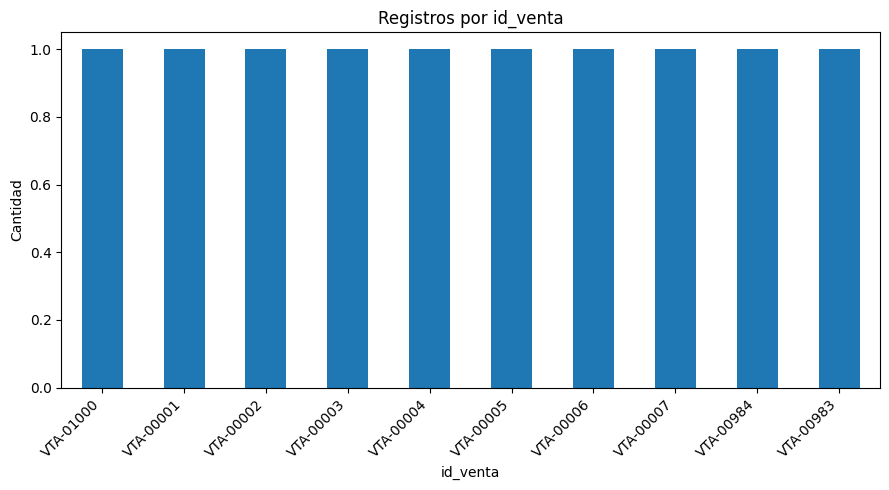

In [125]:
from IPython.display import display, Image

# 1. Carga una tabla permitida y crea las herramientas seguras.
df_prueba = extraer_df_desde_mysql("ventas_analitica")
herramientas_prueba = crear_herramientas_analisis(df_prueba)

# 2. Selecciona una columna automáticamente.
columnas_categoricas = df_prueba.select_dtypes(
    include=["object", "category"]
).columns.tolist()

columnas_numericas = df_prueba.select_dtypes(
    include="number"
).columns.tolist()

if columnas_categoricas:
    columna_prueba = columnas_categoricas[0]
elif columnas_numericas:
    columna_prueba = columnas_numericas[0]
else:
    raise ValueError("No hay columnas disponibles para generar una prueba.")

print(f"Columna seleccionada para la prueba: {columna_prueba}")

# 3. Recupera cada herramienta por nombre.
info_tool = next(
    herramienta
    for herramienta in herramientas_prueba
    if herramienta.name == "informacion_dataset"
)

conteo_tool = next(
    herramienta
    for herramienta in herramientas_prueba
    if herramienta.name == "conteo_por_categoria"
)

grafico_tool = next(
    herramienta
    for herramienta in herramientas_prueba
    if herramienta.name == "generar_grafico"
)

# 4. Prueba información y conteo.
print("\n--- INFORMACIÓN DEL DATASET ---")
print(info_tool.invoke({}))

print("\n--- CONTEO / RESULTADO POR COLUMNA ---")
print(conteo_tool.invoke({"columna": columna_prueba}))

# 5. Genera y muestra el gráfico.
print("\n--- GRÁFICO ---")
print(grafico_tool.invoke({"columna": columna_prueba}))

display(Image(filename="grafico_analisis.png"))

In [126]:
entrada_prueba = {
    "messages": [
        ("user", "Genera un gráfico con la información de ventas disponible.")
    ],
    "user_role": "administrador",
    "tabla_analisis": "ventas_analitica",
}

for salida in app.stream(entrada_prueba):
    print(salida)

🔮 Ejecutando nodo triaje...
💬 Pregunta procesada: 'Genera un gráfico con la información de ventas disponible.' | Rol detectado: administrador
🔮 Decidiendo el flujo después del nodo 'triaje'...
 -> Ruta seleccionada: Módulo de analítica y gráficos
{'triaje': {'triaje': {'decision': 'ANALISIS_DATOS', 'urgencia': 'MEDIANA', 'campos_faltantes': [], 'campo_a_modificar': None, 'nuevo_valor': None}}}
📊 Ejecutando nodo de análisis de datos...


> Entering new AgentExecutor chain...
Do I need to use a tool? Yes

Para generar un gráfico con la información de ventas disponible, primero debo conocer las columnas disponibles en la tabla 'ventas_analitica'. 

Action: informacion_dataset
Action Input: Columnas y tipos:
id_venta                          object
departamento                      object
tipo_operacion                    object
cliente                           object
socio_responsable                 object
canal_origen                      object
ingreso                          float64

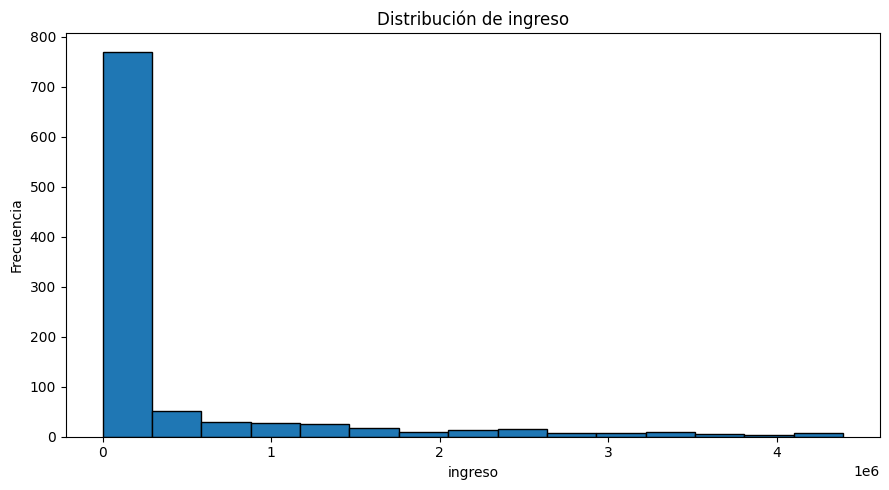

In [127]:
from IPython.display import display, Image
from pathlib import Path

ruta_grafico = Path("grafico_analisis.png")

if ruta_grafico.exists():
    display(Image(filename=str(ruta_grafico)))
else:
    print("No se encontró ningún gráfico generado.")

In [128]:
entrada_prueba = {
    "messages": [
        ("user", "Genera un gráfico de la distribución de ingresos.")
    ],
    "user_role": "administrador",
    "tabla_analisis": "ventas_analitica",
}

for salida in app.stream(entrada_prueba):
    print(salida)

🔮 Ejecutando nodo triaje...
💬 Pregunta procesada: 'Genera un gráfico de la distribución de ingresos.' | Rol detectado: administrador
🔮 Decidiendo el flujo después del nodo 'triaje'...
 -> Ruta seleccionada: Módulo de analítica y gráficos
{'triaje': {'triaje': {'decision': 'ANALISIS_DATOS', 'urgencia': 'MEDIANA', 'campos_faltantes': [], 'campo_a_modificar': None, 'nuevo_valor': None}}}
📊 Ejecutando nodo de análisis de datos...


> Entering new AgentExecutor chain...
Do I need to use a tool? Yes

Para generar un gráfico de la distribución de ingresos, primero debo conocer la estructura de la tabla 'ventas_analitica' y verificar si existe una columna relacionada con los ingresos.

Action: informacion_dataset
Action Input: Columnas y tipos:
id_venta                          object
departamento                      object
tipo_operacion                    object
cliente                           object
socio_responsable                 object
canal_origen                      object
ingreso

#PRUEBAS GENERALES DEL AGENTE
**____________________________________________________________________________**

In [129]:
# EJECUTOR DE PRUEBAS
from pathlib import Path
from IPython.display import display, Image


def ejecutar_caso(nombre: str, entrada: dict, accion_esperada: str | None = None):
    print(f"\n{'=' * 20} {nombre.upper()} {'=' * 20}")

    estado_final = {}

    try:
        for evento in app.stream(entrada):
            for nodo, actualizacion in evento.items():
                print(f"Nodo ejecutado: {nodo}")
                estado_final.update(actualizacion)

        print("\nAcción final:", estado_final.get("accion_final"))
        print("Respuesta:", estado_final.get("respuesta"))

        if accion_esperada:
            if estado_final.get("accion_final") == accion_esperada:
                print("✅ Resultado esperado.")
            else:
                print(
                    f"⚠️ Se esperaba '{accion_esperada}', "
                    f"pero se obtuvo '{estado_final.get('accion_final')}'."
                )

        ruta = estado_final.get("grafico_generado")

        if ruta and Path(ruta).exists():
            display(Image(filename=ruta))

        return estado_final

    except Exception as error:
        print(f"❌ Error durante la prueba: {type(error).__name__}: {error}")
        return None

In [130]:
# 1. RAG: respuesta basada en un PDF real.
ejecutar_caso(
    "Documentación RAG",
    {
        "messages": [
            ("user", "¿Qué requisitos necesito para realizar un trámite catastral?")
        ],
        "user_role": "cliente",
    },
    "DOCUMENTACION_RESUELTA",
)


==================== DOCUMENTACIÓN RAG ====================
🔮 Ejecutando nodo triaje...
💬 Pregunta procesada: '¿Qué requisitos necesito para realizar un trámite catastral?' | Rol detectado: cliente
🔮 Decidiendo el flujo después del nodo 'triaje'...
 -> Ruta seleccionada: Base de Conocimiento (RAG)
Nodo ejecutado: triaje
📚 Ejecutando nodo consultar_documentacion (RAG)...
📝 Decidiendo el flujo después del nodo 'consultar_documentacion' (RAG)...
RAG exitoso, finalizando el flujo.
Nodo ejecutado: consultar_documentacion

Acción final: DOCUMENTACION_RESUELTA
Respuesta: Para realizar un trámite catastral, se requiere identificación oficial, escritura o documento que acredite la propiedad, comprobante de pago de predial y comprobante de domicilio. Sin embargo, es importante destacar que los requisitos pueden variar según el servicio específico que se desee realizar. En general, para trámites catastrales, se solicita identificación oficial del comprador y vendedor, documentación que acredite 

{'triaje': {'decision': 'CONSULTAR_DOCUMENTACION',
  'urgencia': 'MEDIANA',
  'campos_faltantes': [],
  'campo_a_modificar': None,
  'nuevo_valor': None},
 'respuesta': 'Para realizar un trámite catastral, se requiere identificación oficial, escritura o documento que acredite la propiedad, comprobante de pago de predial y comprobante de domicilio. Sin embargo, es importante destacar que los requisitos pueden variar según el servicio específico que se desee realizar. En general, para trámites catastrales, se solicita identificación oficial del comprador y vendedor, documentación que acredite la propiedad del vendedor (como escritura, título agrario o resolución judicial), y plano del predio. Es recomendable consultar con el departamento Administrativo para confirmar los requisitos exactos y el monto de los derechos catastrales vigentes, ya que estos pueden variar y se actualizan anualmente.',
 'citaciones': [Document(id='682177b2-ea4a-449c-8dad-e1a4e5094889', metadata={'producer': 'xdvi

In [131]:
# 2. RAG: pregunta fuera de la documentación.
ejecutar_caso(
    "Documentación no encontrada",
    {
        "messages": [
            ("user", "¿Cuál es el clima de mañana en Guadalajara?")
        ],
        "user_role": "cliente",
    },
    "PEDIR_INFO_CLIENTE",
)


==================== DOCUMENTACIÓN NO ENCONTRADA ====================
🔮 Ejecutando nodo triaje...
💬 Pregunta procesada: '¿Cuál es el clima de mañana en Guadalajara?' | Rol detectado: cliente
🔮 Decidiendo el flujo después del nodo 'triaje'...
 -> Ruta seleccionada: Pedir más información / Caso ambiguo
Nodo ejecutado: triaje
💬 Ejecutando nodo pedir_info...
Nodo ejecutado: pedir_info

Acción final: PEDIR_INFO_CLIENTE
Respuesta: Para poder ayudarte mejor en Terrenos TOPO, ¿podrías ser un poco más específico con tu consulta o indicarme con qué departamento deseas hablar?
✅ Resultado esperado.


{'triaje': {'decision': 'PEDIR_INFO',
  'urgencia': 'BAJA',
  'campos_faltantes': [],
  'campo_a_modificar': None,
  'nuevo_valor': None},
 'respuesta': 'Para poder ayudarte mejor en Terrenos TOPO, ¿podrías ser un poco más específico con tu consulta o indicarme con qué departamento deseas hablar?',
 'accion_final': 'PEDIR_INFO_CLIENTE'}

In [132]:
# 3. Cliente: catálogo público, solo propiedades disponibles.
ejecutar_caso(
    "Cliente consulta inventario público",
    {
        "messages": [
            ("user", "¿Qué terrenos en venta tienen disponibles?")
        ],
        "user_role": "cliente",
    },
    "CONSULTA_DB_PROCESADA",
)


==================== CLIENTE CONSULTA INVENTARIO PÚBLICO ====================
🔮 Ejecutando nodo triaje...
💬 Pregunta procesada: '¿Qué terrenos en venta tienen disponibles?' | Rol detectado: cliente
🔮 Decidiendo el flujo después del nodo 'triaje'...
 -> Ruta seleccionada: Consulta de datos/expedientes (MySQL)
Nodo ejecutado: triaje
🗄️ Ejecutando nodo consultar_db...
Nodo ejecutado: consultar_db

Acción final: CONSULTA_DB_PROCESADA
Respuesta: [{'clave_terreno': 'TT-0101', 'ubicacion': 'San Isidro, Timilpan, Edo. Méx.', 'superficie_m2': Decimal('48484.72'), 'uso_suelo': 'Industrial', 'precio_m2': Decimal('233.56'), 'precio_total': Decimal('11324091.20'), 'estatus': 'disponible'}, {'clave_terreno': 'TT-0102', 'ubicacion': 'Barrio de Guadalupe, Chapa de Mota, Edo. Méx.', 'superficie_m2': Decimal('1801.43'), 'uso_suelo': 'Agricola / inversion', 'precio_m2': Decimal('196.09'), 'precio_total': Decimal('353242.41'), 'estatus': 'disponible'}, {'clave_terreno': 'TT-0104', 'ubicacion': 'Los Encin

{'triaje': {'decision': 'CONSULTAR_DB',
  'urgencia': 'BAJA',
  'campos_faltantes': [],
  'campo_a_modificar': None,
  'nuevo_valor': None},
 'respuesta': "[{'clave_terreno': 'TT-0101', 'ubicacion': 'San Isidro, Timilpan, Edo. Méx.', 'superficie_m2': Decimal('48484.72'), 'uso_suelo': 'Industrial', 'precio_m2': Decimal('233.56'), 'precio_total': Decimal('11324091.20'), 'estatus': 'disponible'}, {'clave_terreno': 'TT-0102', 'ubicacion': 'Barrio de Guadalupe, Chapa de Mota, Edo. Méx.', 'superficie_m2': Decimal('1801.43'), 'uso_suelo': 'Agricola / inversion', 'precio_m2': Decimal('196.09'), 'precio_total': Decimal('353242.41'), 'estatus': 'disponible'}, {'clave_terreno': 'TT-0104', 'ubicacion': 'Los Encinos, Aculco, Edo. Méx.', 'superficie_m2': Decimal('41187.75'), 'uso_suelo': 'Campestre / agricola', 'precio_m2': Decimal('223.17'), 'precio_total': Decimal('9191870.17'), 'estatus': 'disponible'}, {'clave_terreno': 'TT-0105', 'ubicacion': 'La Loma, Jilotepec de Molina Enríquez, Edo. Méx.', 

In [133]:
# 4. Cliente: consulta su propio trámite con folio coincidente.
ejecutar_caso(
    "Cliente consulta su propio trámite",
    {
        "messages": [
            ("user", "¿Cuál es el estado del trámite TOP-00001?")
        ],
        "user_role": "cliente",
        "user_folio": "TOP-00001",
    },
    "CONSULTA_DB_PROCESADA",
)


==================== CLIENTE CONSULTA SU PROPIO TRÁMITE ====================
🔮 Ejecutando nodo triaje...
💬 Pregunta procesada: '¿Cuál es el estado del trámite TOP-00001?' | Rol detectado: cliente
🔮 Decidiendo el flujo después del nodo 'triaje'...
 -> Ruta seleccionada: Consulta de datos/expedientes (MySQL)
Nodo ejecutado: triaje
🗄️ Ejecutando nodo consultar_db...
📌 Folio detectado para consulta: TOP-00001
Nodo ejecutado: consultar_db

Acción final: CONSULTA_DB_PROCESADA
Respuesta: [{'id_proyecto': 'TOP-00001', 'ubicacion': 'Los Encinos, Aculco, Edo. Méx.', 'propietario': 'Alberto Hernán Guevara', 'tipo_proyecto': 'Calculo de areas y volumenes', 'costo_total': Decimal('2668.98'), 'anticipo': Decimal('1334.49'), 'restante': Decimal('0.00'), 'estatus': 'en_desarrollo', 'fecha_inicio': datetime.date(2024, 9, 7), 'fecha_estimada_entrega': datetime.date(2024, 9, 21)}]
✅ Resultado esperado.


{'triaje': {'decision': 'CONSULTAR_DB',
  'urgencia': 'MEDIANA',
  'campos_faltantes': [],
  'campo_a_modificar': None,
  'nuevo_valor': None},
 'respuesta': "[{'id_proyecto': 'TOP-00001', 'ubicacion': 'Los Encinos, Aculco, Edo. Méx.', 'propietario': 'Alberto Hernán Guevara', 'tipo_proyecto': 'Calculo de areas y volumenes', 'costo_total': Decimal('2668.98'), 'anticipo': Decimal('1334.49'), 'restante': Decimal('0.00'), 'estatus': 'en_desarrollo', 'fecha_inicio': datetime.date(2024, 9, 7), 'fecha_estimada_entrega': datetime.date(2024, 9, 21)}]",
 'accion_final': 'CONSULTA_DB_PROCESADA',
 'folio_consultado': 'TOP-00001'}

In [134]:
# 5. Cliente: intenta consultar un folio ajeno.
ejecutar_caso(
    "Cliente intenta consultar trámite ajeno",
    {
        "messages": [
            ("user", "¿Cuál es el estado del trámite TOP-00002?")
        ],
        "user_role": "cliente",
        "user_folio": "TOP-00001",
    },
    "CONSULTA_DB_PROCESADA",
)


==================== CLIENTE INTENTA CONSULTAR TRÁMITE AJENO ====================
🔮 Ejecutando nodo triaje...
💬 Pregunta procesada: '¿Cuál es el estado del trámite TOP-00002?' | Rol detectado: cliente
🔮 Decidiendo el flujo después del nodo 'triaje'...
 -> Ruta seleccionada: Consulta de datos/expedientes (MySQL)
Nodo ejecutado: triaje
🗄️ Ejecutando nodo consultar_db...
📌 Folio detectado para consulta: TOP-00002
Nodo ejecutado: consultar_db

Acción final: CONSULTA_DB_PROCESADA
Respuesta: Acceso Denegado: Tu rol de 'cliente' no tiene permisos para consultar la tabla 'topografia_proyectos' o el folio especificado no te pertenece.
✅ Resultado esperado.


{'triaje': {'decision': 'CONSULTAR_DB',
  'urgencia': 'MEDIANA',
  'campos_faltantes': [],
  'campo_a_modificar': None,
  'nuevo_valor': None},
 'respuesta': "Acceso Denegado: Tu rol de 'cliente' no tiene permisos para consultar la tabla 'topografia_proyectos' o el folio especificado no te pertenece.",
 'accion_final': 'CONSULTA_DB_PROCESADA',
 'folio_consultado': 'TOP-00002'}

In [135]:
# 6. Empleado: consulta general a BD.
ejecutar_caso(
    "Empleado consulta BD",
    {
        "messages": [
            ("user", "Consulta la información del terreno TT-0101.")
        ],
        "user_role": "empleado",
    },
    "CONSULTA_DB_PROCESADA",
)


==================== EMPLEADO CONSULTA BD ====================
🔮 Ejecutando nodo triaje...
💬 Pregunta procesada: 'Consulta la información del terreno TT-0101.' | Rol detectado: empleado
🔮 Decidiendo el flujo después del nodo 'triaje'...
 -> Ruta seleccionada: Consulta de datos/expedientes (MySQL)
Nodo ejecutado: triaje
🗄️ Ejecutando nodo consultar_db...
📌 Folio detectado para consulta: TT-0101
Nodo ejecutado: consultar_db

Acción final: CONSULTA_DB_PROCESADA
Respuesta: [{'clave_terreno': 'TT-0101', 'ubicacion': 'San Isidro, Timilpan, Edo. Méx.', 'superficie_m2': Decimal('48484.72'), 'uso_suelo': 'Industrial', 'precio_m2': Decimal('233.56'), 'precio_total': Decimal('11324091.20'), 'documentos_disponibles': 'certificado de no adeudo, titulo agrario', 'enganche_minimo': Decimal('2264818.24'), 'estatus': 'disponible', 'socio_asignado': 'Sofia Ramirez Cortes'}]
✅ Resultado esperado.


{'triaje': {'decision': 'CONSULTAR_DB',
  'urgencia': 'MEDIANA',
  'campos_faltantes': [],
  'campo_a_modificar': None,
  'nuevo_valor': None},
 'respuesta': "[{'clave_terreno': 'TT-0101', 'ubicacion': 'San Isidro, Timilpan, Edo. Méx.', 'superficie_m2': Decimal('48484.72'), 'uso_suelo': 'Industrial', 'precio_m2': Decimal('233.56'), 'precio_total': Decimal('11324091.20'), 'documentos_disponibles': 'certificado de no adeudo, titulo agrario', 'enganche_minimo': Decimal('2264818.24'), 'estatus': 'disponible', 'socio_asignado': 'Sofia Ramirez Cortes'}]",
 'accion_final': 'CONSULTA_DB_PROCESADA',
 'folio_consultado': 'TT-0101'}

In [136]:
# 7. Administrador: consulta general a BD.
ejecutar_caso(
    "Administrador consulta BD",
    {
        "messages": [
            ("user", "Consulta la información del terreno TT-0101.")
        ],
        "user_role": "administrador",
    },
    "CONSULTA_DB_PROCESADA",
)


==================== ADMINISTRADOR CONSULTA BD ====================
🔮 Ejecutando nodo triaje...
💬 Pregunta procesada: 'Consulta la información del terreno TT-0101.' | Rol detectado: administrador
🔮 Decidiendo el flujo después del nodo 'triaje'...
 -> Ruta seleccionada: Consulta de datos/expedientes (MySQL)
Nodo ejecutado: triaje
🗄️ Ejecutando nodo consultar_db...
📌 Folio detectado para consulta: TT-0101
Nodo ejecutado: consultar_db

Acción final: CONSULTA_DB_PROCESADA
Respuesta: [{'clave_terreno': 'TT-0101', 'ubicacion': 'San Isidro, Timilpan, Edo. Méx.', 'superficie_m2': Decimal('48484.72'), 'uso_suelo': 'Industrial', 'precio_m2': Decimal('233.56'), 'precio_total': Decimal('11324091.20'), 'documentos_disponibles': 'certificado de no adeudo, titulo agrario', 'enganche_minimo': Decimal('2264818.24'), 'estatus': 'disponible', 'socio_asignado': 'Sofia Ramirez Cortes'}]
✅ Resultado esperado.


{'triaje': {'decision': 'CONSULTAR_DB',
  'urgencia': 'MEDIANA',
  'campos_faltantes': [],
  'campo_a_modificar': None,
  'nuevo_valor': None},
 'respuesta': "[{'clave_terreno': 'TT-0101', 'ubicacion': 'San Isidro, Timilpan, Edo. Méx.', 'superficie_m2': Decimal('48484.72'), 'uso_suelo': 'Industrial', 'precio_m2': Decimal('233.56'), 'precio_total': Decimal('11324091.20'), 'documentos_disponibles': 'certificado de no adeudo, titulo agrario', 'enganche_minimo': Decimal('2264818.24'), 'estatus': 'disponible', 'socio_asignado': 'Sofia Ramirez Cortes'}]",
 'accion_final': 'CONSULTA_DB_PROCESADA',
 'folio_consultado': 'TT-0101'}

In [137]:
# 8. Empleado: genera una solicitud; ESTA PRUEBA INSERTA UN REGISTRO
# en administrativo_solicitudes.
ejecutar_caso(
    "Empleado solicita modificación",
    {
        "messages": [
            ("user", "Actualiza el estatus de TT-0101 a Disponible.")
        ],
        "user_role": "empleado",
    },
    "MODIFICACION_EXITOSA",
)


==================== EMPLEADO SOLICITA MODIFICACIÓN ====================
🔮 Ejecutando nodo triaje...
💬 Pregunta procesada: 'Actualiza el estatus de TT-0101 a Disponible.' | Rol detectado: empleado
🔮 Decidiendo el flujo después del nodo 'triaje'...
 -> Ruta seleccionada: Modificación de registros
Nodo ejecutado: triaje
✍️ Ejecutando nodo modificar_db_o_docs...
📝 Registrando nueva solicitud de modificación para el folio TT-0101...
Nodo ejecutado: modificar_db

Acción final: MODIFICACION_EXITOSA
Respuesta: Tu solicitud para modificar el folio 'TT-0101' ha sido registrada exitosamente. Un Administrador revisará el cambio sugerido (estatus -> Disponible) a la brevedad.
✅ Resultado esperado.


{'triaje': {'decision': 'MODIFICAR_DB_O_DOCS',
  'urgencia': 'MEDIANA',
  'campos_faltantes': ['folio'],
  'campo_a_modificar': 'estatus',
  'nuevo_valor': 'Disponible'},
 'respuesta': "Tu solicitud para modificar el folio 'TT-0101' ha sido registrada exitosamente. Un Administrador revisará el cambio sugerido (estatus -> Disponible) a la brevedad.",
 'accion_final': 'MODIFICACION_EXITOSA'}

In [138]:
# 9. Administrador: se solicita confirmación; no modifica la BD.
ejecutar_caso(
    "Administrador sin confirmación",
    {
        "messages": [
            ("user", "Actualiza el estatus de TT-0101 a Disponible.")
        ],
        "user_role": "administrador",
        "confirmacion_modificacion": False,
    },
    "CONFIRMACION_REQUERIDA",
)


==================== ADMINISTRADOR SIN CONFIRMACIÓN ====================
🔮 Ejecutando nodo triaje...
💬 Pregunta procesada: 'Actualiza el estatus de TT-0101 a Disponible.' | Rol detectado: administrador
🔮 Decidiendo el flujo después del nodo 'triaje'...
 -> Ruta seleccionada: Modificación de registros
Nodo ejecutado: triaje
✍️ Ejecutando nodo modificar_db_o_docs...
Nodo ejecutado: modificar_db

Acción final: CONFIRMACION_REQUERIDA
Respuesta: Confirmación requerida: se modificará 'estatus' del folio 'TT-0101' al valor 'Disponible'.
✅ Resultado esperado.


{'triaje': {'decision': 'MODIFICAR_DB_O_DOCS',
  'urgencia': 'MEDIANA',
  'campos_faltantes': ['folio'],
  'campo_a_modificar': 'estatus',
  'nuevo_valor': 'Disponible'},
 'respuesta': "Confirmación requerida: se modificará 'estatus' del folio 'TT-0101' al valor 'Disponible'.",
 'accion_final': 'CONFIRMACION_REQUERIDA'}


==================== ADMINISTRADOR ANALIZA VENTAS ====================
🔮 Ejecutando nodo triaje...
💬 Pregunta procesada: 'Genera un gráfico de la distribución de ingresos.' | Rol detectado: administrador
🔮 Decidiendo el flujo después del nodo 'triaje'...
 -> Ruta seleccionada: Módulo de analítica y gráficos
Nodo ejecutado: triaje
📊 Ejecutando nodo de análisis de datos...


> Entering new AgentExecutor chain...
Do I need to use a tool? Yes
Action: informacion_dataset
Action Input: Columnas y tipos:
id_venta                          object
departamento                      object
tipo_operacion                    object
cliente                           object
socio_responsable                 object
canal_origen                      object
ingreso                          float64
costo_operativo                  float64
utilidad                         float64
fecha_inicio_proceso      datetime64[ns]
fecha_cierre              datetime64[ns]
dias_duracion_proceso              int64
anio

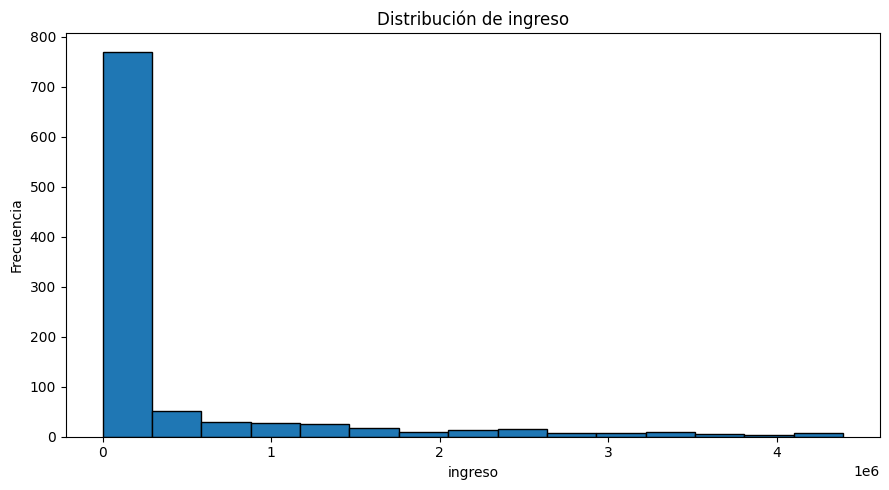

{'triaje': {'decision': 'ANALISIS_DATOS',
  'urgencia': 'MEDIANA',
  'campos_faltantes': [],
  'campo_a_modificar': None,
  'nuevo_valor': None},
 'respuesta': "Se ha generado un gráfico que muestra la distribución de los ingresos en la tabla 'ventas_analitica'. El gráfico es un histograma, ya que la columna 'ingreso' es de tipo numérico. Esto permite visualizar la frecuencia y la concentración de los ingresos en diferentes rangos, lo que puede ser útil para identificar patrones y tendencias en los datos. El gráfico se encuentra almacenado en el archivo 'grafico_analisis.png' y puede ser utilizado para realizar un análisis más detallado de la distribución de los ingresos.",
 'accion_final': 'ANALISIS_COMPLETADO',
 'grafico_generado': 'grafico_analisis.png'}

In [139]:
# 10. Administrador: análisis y gráfico.
ejecutar_caso(
    "Administrador analiza ventas",
    {
        "messages": [
            ("user", "Genera un gráfico de la distribución de ingresos.")
        ],
        "user_role": "administrador",
        "tabla_analisis": "ventas_analitica",
    },
    "ANALISIS_COMPLETADO",
)

In [146]:
# 11. Empleado: análisis autorizado.
ejecutar_caso(
    "Empleado analiza ventas",
    {
        "messages": [
            ("user", "Muestra un resumen estadístico de las ventas.")
        ],
        "user_role": "empleado",
        "tabla_analisis": "ventas_analitica",
    },
    "ANALISIS_COMPLETADO",
)


==================== EMPLEADO ANALIZA VENTAS ====================
🔮 Ejecutando nodo triaje...
💬 Pregunta procesada: 'Muestra un resumen estadístico de las ventas.' | Rol detectado: empleado
🔮 Decidiendo el flujo después del nodo 'triaje'...
 -> Ruta seleccionada: Módulo de analítica y gráficos
Nodo ejecutado: triaje
📊 Ejecutando nodo de análisis de datos...


> Entering new AgentExecutor chain...
Do I need to use a tool? Yes
Action: resumen_estadistico
Action Input:          id_venta   departamento                 tipo_operacion                  cliente   socio_responsable         canal_origen        ingreso costo_operativo       utilidad           fecha_inicio_proceso                fecha_cierre dias_duracion_proceso      anio       mes trimestre metodo_pago financiamiento_directo satisfaccion_cliente
count        1000           1000                           1000                     1000                1000                 1000         1000.0          1000.0         1000.0          

In [141]:
# 12. Cliente: análisis denegado.
ejecutar_caso(
    "Cliente intenta analizar datos",
    {
        "messages": [
            ("user", "Genera un gráfico de los ingresos.")
        ],
        "user_role": "cliente",
        "tabla_analisis": "ventas_analitica",
    },
    "ACCESO_ANALISIS_DENEGADO",
)


==================== CLIENTE INTENTA ANALIZAR DATOS ====================
🔮 Ejecutando nodo triaje...
💬 Pregunta procesada: 'Genera un gráfico de los ingresos.' | Rol detectado: cliente
⚠️ Error en triaje, usando fallback PEDIR_INFO: Error code: 429 - {'error': {'message': 'Rate limit reached for model `llama-3.3-70b-versatile` in organization `org_01kw65n409ersa12vn16msmans` service tier `on_demand` on tokens per day (TPD): Limit 100000, Used 99755, Requested 632. Please try again in 5m34.368s. Need more tokens? Upgrade to Dev Tier today at https://console.groq.com/settings/billing', 'type': 'tokens', 'code': 'rate_limit_exceeded'}}
🔮 Decidiendo el flujo después del nodo 'triaje'...
 -> Ruta seleccionada: Pedir más información / Caso ambiguo
Nodo ejecutado: triaje
💬 Ejecutando nodo pedir_info...
Nodo ejecutado: pedir_info

Acción final: PEDIR_INFO_CLIENTE
Respuesta: Para poder ayudarte mejor en Terrenos TOPO, ¿podrías ser un poco más específico con tu consulta o indicarme con qué depa

{'triaje': {'decision': 'PEDIR_INFO',
  'urgencia': 'BAJA',
  'campos_faltantes': [],
  'campo_a_modificar': None,
  'nuevo_valor': None},
 'respuesta': 'Para poder ayudarte mejor en Terrenos TOPO, ¿podrías ser un poco más específico con tu consulta o indicarme con qué departamento deseas hablar?',
 'accion_final': 'PEDIR_INFO_CLIENTE'}

# REVISAR PRUEBA 13, ALMACENAR DATOS PARA CITA

In [142]:
# 13. Agendar cita.
ejecutar_caso(
    "Solicitud de cita",
    {
        "messages": [
            ("user", "Quiero agendar una cita para hablar sobre un levantamiento topográfico.")
        ],
        "user_role": "cliente",
    },
    "SOLICITAR_DATOS_CITA",
)


==================== SOLICITUD DE CITA ====================
🔮 Ejecutando nodo triaje...
💬 Pregunta procesada: 'Quiero agendar una cita para hablar sobre un levantamiento topográfico.' | Rol detectado: cliente
⚠️ Error en triaje, usando fallback PEDIR_INFO: Error code: 429 - {'error': {'message': 'Rate limit reached for model `llama-3.3-70b-versatile` in organization `org_01kw65n409ersa12vn16msmans` service tier `on_demand` on tokens per day (TPD): Limit 100000, Used 99755, Requested 717. Please try again in 6m47.808s. Need more tokens? Upgrade to Dev Tier today at https://console.groq.com/settings/billing', 'type': 'tokens', 'code': 'rate_limit_exceeded'}}
🔮 Decidiendo el flujo después del nodo 'triaje'...
 -> Ruta seleccionada: Pedir más información / Caso ambiguo
Nodo ejecutado: triaje
💬 Ejecutando nodo pedir_info...
Nodo ejecutado: pedir_info

Acción final: PEDIR_INFO_CLIENTE
Respuesta: Para poder ayudarte mejor en Terrenos TOPO, ¿podrías ser un poco más específico con tu consulta 

{'triaje': {'decision': 'PEDIR_INFO',
  'urgencia': 'BAJA',
  'campos_faltantes': [],
  'campo_a_modificar': None,
  'nuevo_valor': None},
 'respuesta': 'Para poder ayudarte mejor en Terrenos TOPO, ¿podrías ser un poco más específico con tu consulta o indicarme con qué departamento deseas hablar?',
 'accion_final': 'PEDIR_INFO_CLIENTE'}

In [143]:
# 14. Consulta ambigua.
ejecutar_caso(
    "Consulta ambigua",
    {
        "messages": [
            ("user", "Hola, necesito ayuda.")
        ],
        "user_role": "cliente",
    },
    "PEDIR_INFO_CLIENTE",
)


==================== CONSULTA AMBIGUA ====================
🔮 Ejecutando nodo triaje...
💬 Pregunta procesada: 'Hola, necesito ayuda.' | Rol detectado: cliente
⚠️ Error en triaje, usando fallback PEDIR_INFO: Error code: 429 - {'error': {'message': 'Rate limit reached for model `llama-3.3-70b-versatile` in organization `org_01kw65n409ersa12vn16msmans` service tier `on_demand` on tokens per day (TPD): Limit 100000, Used 99755, Requested 628. Please try again in 5m30.912s. Need more tokens? Upgrade to Dev Tier today at https://console.groq.com/settings/billing', 'type': 'tokens', 'code': 'rate_limit_exceeded'}}
🔮 Decidiendo el flujo después del nodo 'triaje'...
 -> Ruta seleccionada: Pedir más información / Caso ambiguo
Nodo ejecutado: triaje
💬 Ejecutando nodo pedir_info...
Nodo ejecutado: pedir_info

Acción final: PEDIR_INFO_CLIENTE
Respuesta: Para poder ayudarte mejor en Terrenos TOPO, ¿podrías ser un poco más específico con tu consulta o indicarme con qué departamento deseas hablar?
✅ R

{'triaje': {'decision': 'PEDIR_INFO',
  'urgencia': 'BAJA',
  'campos_faltantes': [],
  'campo_a_modificar': None,
  'nuevo_valor': None},
 'respuesta': 'Para poder ayudarte mejor en Terrenos TOPO, ¿podrías ser un poco más específico con tu consulta o indicarme con qué departamento deseas hablar?',
 'accion_final': 'PEDIR_INFO_CLIENTE'}

In [144]:
# Catálogo general: solo disponibles y campos públicos.
print(
    consulta_base_de_datos(
        "¿Qué terrenos en venta tienen disponibles?",
        user_role="cliente",
    )
)

[{'clave_terreno': 'TT-0101', 'ubicacion': 'San Isidro, Timilpan, Edo. Méx.', 'superficie_m2': Decimal('48484.72'), 'uso_suelo': 'Industrial', 'precio_m2': Decimal('233.56'), 'precio_total': Decimal('11324091.20'), 'estatus': 'disponible'}, {'clave_terreno': 'TT-0102', 'ubicacion': 'Barrio de Guadalupe, Chapa de Mota, Edo. Méx.', 'superficie_m2': Decimal('1801.43'), 'uso_suelo': 'Agricola / inversion', 'precio_m2': Decimal('196.09'), 'precio_total': Decimal('353242.41'), 'estatus': 'disponible'}, {'clave_terreno': 'TT-0104', 'ubicacion': 'Los Encinos, Aculco, Edo. Méx.', 'superficie_m2': Decimal('41187.75'), 'uso_suelo': 'Campestre / agricola', 'precio_m2': Decimal('223.17'), 'precio_total': Decimal('9191870.17'), 'estatus': 'disponible'}, {'clave_terreno': 'TT-0105', 'ubicacion': 'La Loma, Jilotepec de Molina Enríquez, Edo. Méx.', 'superficie_m2': Decimal('2463.38'), 'uso_suelo': 'Habitacional', 'precio_m2': Decimal('430.70'), 'precio_total': Decimal('1060977.77'), 'estatus': 'disponi

In [145]:
# Terreno específico: tampoco debe mostrar datos sensibles.
print(
    consulta_base_de_datos(
        "Dame información del terreno TT-0101",
        user_role="cliente",
    )
)

[{'clave_terreno': 'TT-0101', 'ubicacion': 'San Isidro, Timilpan, Edo. Méx.', 'superficie_m2': Decimal('48484.72'), 'uso_suelo': 'Industrial', 'precio_m2': Decimal('233.56'), 'precio_total': Decimal('11324091.20'), 'estatus': 'disponible'}]
